# 02 - Descriptive Analysis

Summary statistics and descriptive visualisations for the dataset including figures: 
- Map of LADs scraped 
- histogram of comments 
- boxplots of comments by housing type 
- scatterplot of comments vs units 

In [1]:
import sys
sys.path.append("../functions")

import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import geopandas as gpd

from config import RESULTS_DIR, FIGURES_DIR, HOUSING_TYPE_COLOURS, HOUSING_ORDER, INNER_LONDON_BOROUGHS
from data_loader import load_london_lad

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## Load prepared data

In [2]:
comment_df    = pd.read_parquet(RESULTS_DIR / "comments.parquet")
application_df = pd.read_parquet(RESULTS_DIR / "applications.parquet")
london_lad     = load_london_lad()

print(f"Comments:     {len(comment_df):,}")
print(f"Applications: {len(application_df):,}")

Comments:     30,393
Applications: 5,235


## Summary statistics
These are the numbers in Table 1 of the paper. 

In [3]:
overall = {
    "total_applications":                  application_df["lpa_app_no"].nunique(),
    "total_proposed_residential_units":    application_df["total_no_proposed_residential_units"].sum(),
    "total_comments":                      application_df["comment_count"].sum(),
    "mean_comments_per_application":       application_df["comment_count"].mean().round(2),
}
pd.Series(overall).rename("value")

total_applications                   5071.00
total_proposed_residential_units    66485.00
total_comments                      30399.00
mean_comments_per_application           5.81
Name: value, dtype: float64

In [4]:
# Per-council stats
council_stats = (
    application_df
    .groupby("borough")
    .agg(
        total_applications=("lpa_app_no", "count"),
        total_proposed_units=("total_no_proposed_residential_units", "sum"),
        total_comments=("comment_count", "sum"),
        mean_comments=("comment_count", "mean"),
    )
    .reset_index()
)
council_stats

,borough,total_applications,total_proposed_units,total_comments,mean_comments
0,Barnet,1308,10128,9262,7.081040
1,Brent,935,12509,2291,2.450267
2,City of London,21,3899,38,1.809524
3,Ealing,1123,12182,11314,10.074800
4,Lambeth,546,3347,2834,5.190476
5,Newham,497,11264,922,1.855131
6,Southwark,308,7054,2396,7.779221
7,Westminster,497,6102,1342,2.700201


## Map of included local authorities

In [ ]:
# Load boundaries of LPAs
london_lpa = gpd.read_file('../data/london_geos/local-planning-authority-london.geojson')

additional_lpas = london_lpa[london_lpa['new_lpa_names'].isin(['LLDC', 'OPDC'])].copy()
additional_lpas['centroid_x'] = additional_lpas.geometry.centroid.x
additional_lpas['centroid_y'] = additional_lpas.geometry.centroid.y

/var/folders/4n/x6w1yfcx01qbymrsfpz4ybq00000gn/T/ipykernel_18251/728480703.py:8: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  additional_lpas['centroid_x'] = additional_lpas.geometry.centroid.x
/var/folders/4n/x6w1yfcx01qbymrsfpz4ybq00000gn/T/ipykernel_18251/728480703.py:9: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  additional_lpas['centroid_y'] = additional_lpas.geometry.centroid.y


In [6]:
included_lads = list(application_df["borough"].unique())

In [7]:
# function for assigning location of the text label when plotting 
def assign_side(row, minx, maxx, miny, maxy):
    x, y = row['centroid_x'], row['centroid_y']
    # Calculate distances to each edge
    dist_left = abs(x - minx)
    dist_right = abs(maxx - x)
    dist_bottom = abs(y - miny)
    dist_top = abs(maxy - y)

    # Assign side by minimum distance to bounding box edge
    distances = {'left': dist_left, 'right': dist_right, 'top': dist_top, 'bottom': dist_bottom}
    assigned_side = min(distances, key=distances.get)
    return assigned_side

In [ ]:
# Bounding box
minx, miny, maxx, maxy = london_lad.total_bounds
x_margin = (maxx - minx) * 0.05
y_margin = (maxy - miny) * 0.05

highlighted = london_lad[london_lad['LAD24NM'].isin(included_lads)].copy()
highlighted['centroid'] = highlighted.geometry.centroid

# Sort based on y or x using `.apply()` to extract coords
highlighted['centroid_x'] = highlighted['centroid'].apply(lambda point: point.x)
highlighted['centroid_y'] = highlighted['centroid'].apply(lambda point: point.y)

highlighted['side'] = highlighted.apply(assign_side, axis=1, args=(minx, maxx, miny, maxy))

/var/folders/4n/x6w1yfcx01qbymrsfpz4ybq00000gn/T/ipykernel_18251/2435561514.py:7: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  highlighted['centroid'] = highlighted.geometry.to_crs(4326).centroid


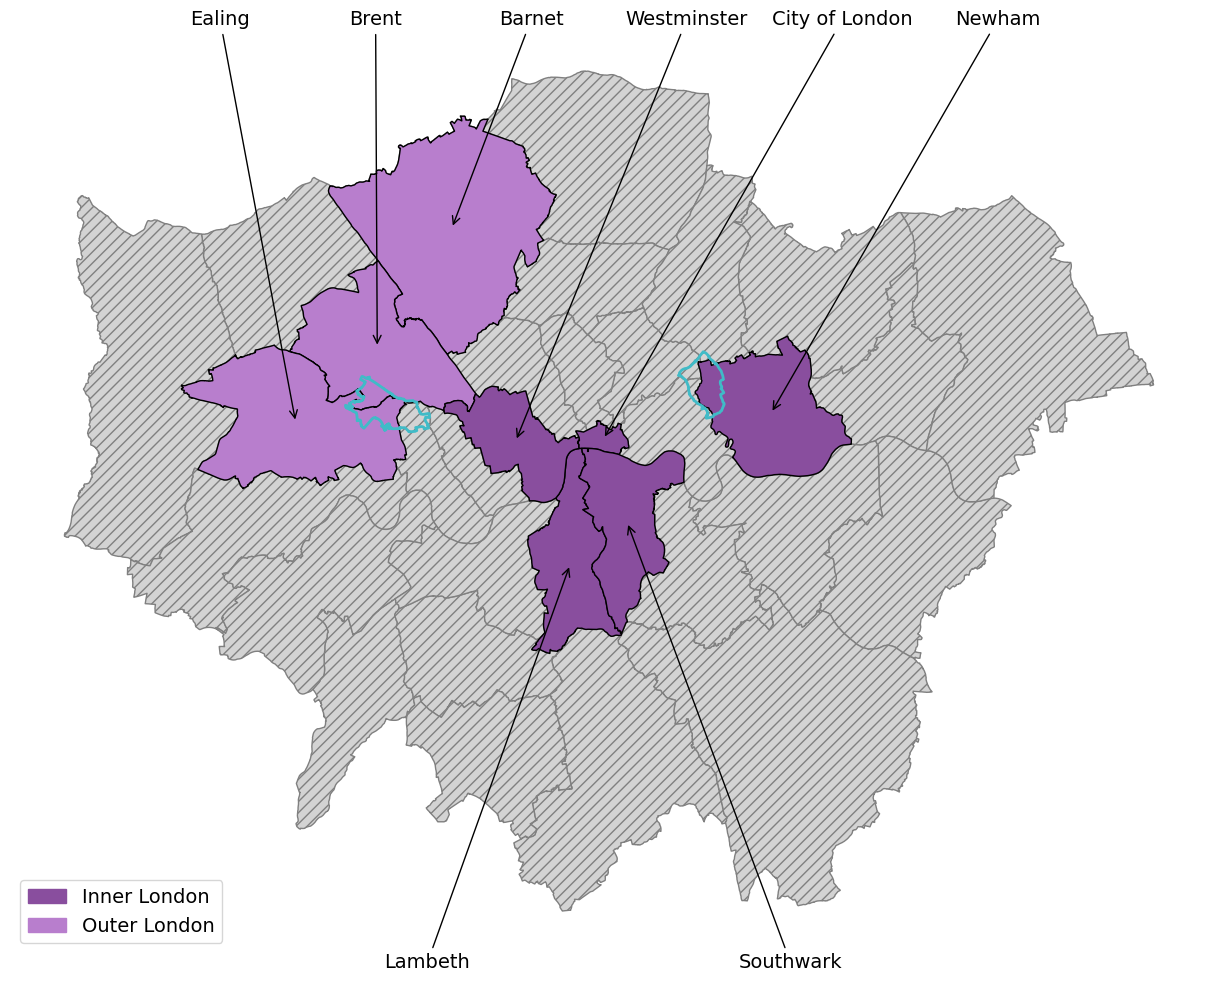

In [ ]:
# Create a new column to indicate if the council is in the councils array
london_lad['highlight'] = london_lad['LAD24NM'].apply(lambda x: x in included_lads)

# colour map by inner and outer london
cmap = {'Inner London': "#894e9e", 'Outer London': "#b87ecd"}
london_lad['colour'] = london_lad['london_area'].map(cmap)

# Plot the GeoDataFrame
fig, ax = plt.subplots(1, 1, figsize=(16, 12))
london_lad.plot(ax=ax, color='lightgrey', edgecolor='grey', hatch="///")  # Default color for all areas

# plot highlighted coouncils (colour coded by inner and outer london)
subset = london_lad[london_lad['highlight']]

subset.plot(
    ax=ax,
    color=subset['colour'],
    edgecolor='black'
)

# add legend for inner and outer london
inner_patch = mpatches.Patch(color="#894e9e", label='Inner London')
outer_patch = mpatches.Patch(color="#b87ecd", label='Outer London')
plt.legend(handles=[inner_patch, outer_patch], loc='lower left', fontsize=14)

# plot additional lpas boundaries
additional_lpas.boundary.plot(ax=ax, color="#40bbc7", linewidth=2, linestyle='---')

def annotate_side(df, side):
    # Sort the df by coordinate axis to get label order
    if side in ['left', 'right']:
       df = df.sort_values(by='centroid_y')  # south → north
    else:  # 'top' or 'bottom'
        df = df.sort_values(by='centroid_x')  # west → east
    
    n = len(df)
    if side in ['left', 'right']:
        # evenly space labels vertically
        y_positions = np.linspace(miny, maxy, n + 2)[1:-1]
        for i, (idx, row) in enumerate(df.iterrows()):
            cx, cy = row['centroid_x'], row['centroid_y']
            if side == 'left':
                lx, ly = minx - x_margin, y_positions[i]
                ha, va = 'right', 'center'
            else:  # right
                lx, ly = maxx + x_margin, y_positions[i]
                ha, va = 'left', 'center'

            ax.annotate(
                row['LAD24NM'],
                xy=(cx, cy),
                xytext=(lx, ly),
                textcoords='data',
                arrowprops=dict(arrowstyle='->', color='black', lw=1),
                fontsize=14,
                ha=ha,
                va=va,
                color='black'
            )
    else:
        # evenly space labels horizontally
        x_positions = np.linspace(minx, maxx, n + 2)[1:-1]
        for i, (idx, row) in enumerate(df.iterrows()):
            cx, cy = row['centroid_x'], row['centroid_y']
            if side == 'top':
                lx, ly = x_positions[i], maxy + y_margin
                ha, va = 'center', 'bottom'
            else:  # bottom
                lx, ly = x_positions[i], miny - y_margin
                ha, va = 'center', 'top'

            ax.annotate(
                row['LAD24NM'],
                xy=(cx, cy),
                xytext=(lx, ly),
                textcoords='data',
                arrowprops=dict(arrowstyle='->', color='black', lw=1),
                fontsize=14,
                ha=ha,
                va=va,
                color='black'
            )

for side, group in highlighted.groupby('side'):
    annotate_side(group, side)

ax.set_axis_off()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "london_lad_map.png", dpi=150, bbox_inches="tight")
plt.show()

## Comment-count distributions

/var/folders/4n/x6w1yfcx01qbymrsfpz4ybq00000gn/T/ipykernel_18251/1907387607.py:96: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0, 10000)


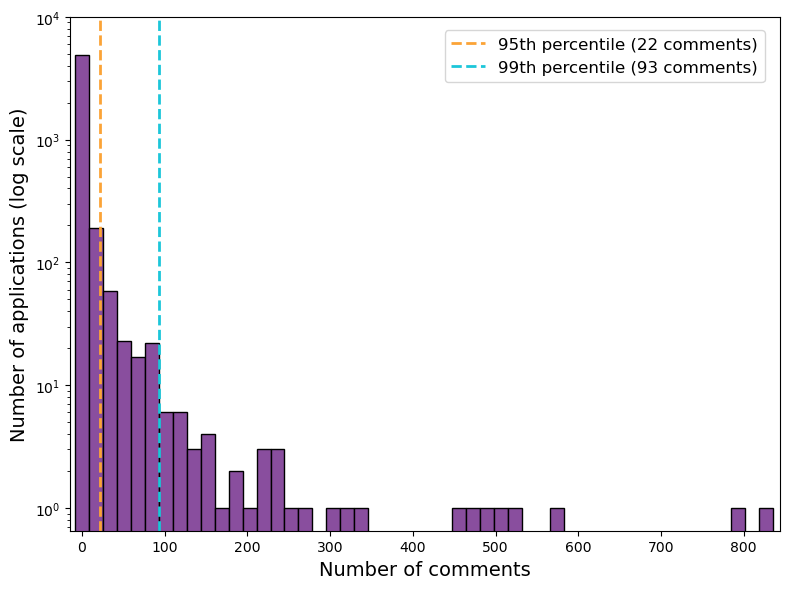

In [ ]:
plt.figure(figsize=(8, 6))

all_comments = application_df["comment_count"].dropna()

# Histogram
counts, bins, patches = plt.hist(
    application_df['comment_count'],
    bins=50,
    stacked=True,
    color=["#894e9e"],
    edgecolor="black",
    align="left",
    zorder=1
)

# 95th percentile
# plot on top of histogram to make it more visible
p95 = np.percentile(all_comments, 95)

plt.axvline(
    p95,
    color="#fba337",
    linestyle="--",
    linewidth=2,
    label=f"95th percentile ({p95:.0f} comments)"
)

p99 = np.percentile(all_comments, 99)
plt.axvline(
    p99,
    color="#1cc6d9",
    linestyle="--",
    linewidth=2,
    label=f"99th percentile ({p99:.0f} comments)"
)

plt.yscale("log")
plt.ylim(0, 10000)
plt.xlim(-15, all_comments.max())

# Set specific tick marks y axis at 1, 10, 100, 1000, 10000
plt.yticks([1, 10, 100, 1000, 10000], ['1', '10', '100', '1000', '10,000'])
plt.xlabel("Number of comments", fontsize=14)
plt.ylabel("Number of applications (log scale)", fontsize=14)
plt.legend(bbox_to_anchor=(0.99, 0.99), fontsize=12)

plt.suptitle("")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "comment_count_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

## Units vs comments scatter (by housing type)

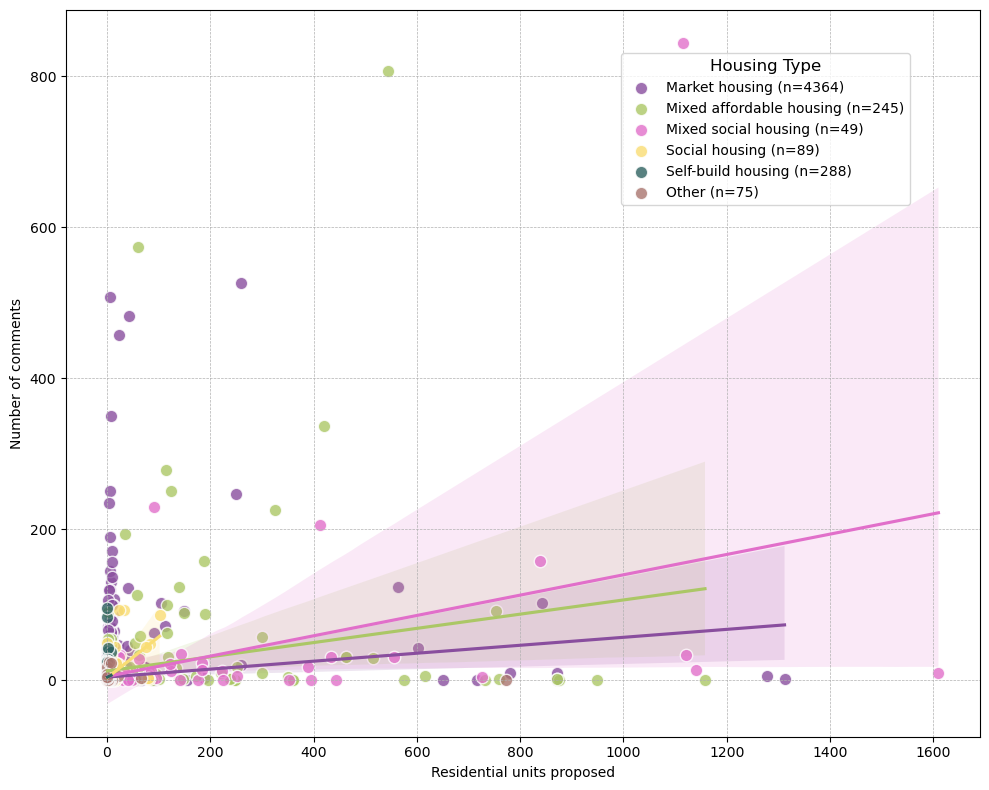

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))
for ht in HOUSING_ORDER:
    sub = application_df[application_df["housing_type"] == ht]
    if sub.empty:
        continue
    if sub["housing_type"].iloc[0] != "Other":
    # Fit a line of best fit using seaborn 
        sns.regplot(
            x= sub["total_no_proposed_residential_units"],
            y= sub["comment_count"],
            scatter=False,
            ax=plt.gca(),
            color=HOUSING_TYPE_COLOURS.get(ht, "grey"),
            ci=95
        )
    ax.scatter(
        sub["total_no_proposed_residential_units"],
        sub["comment_count"],
        color=HOUSING_TYPE_COLOURS.get(ht, "grey"),
        label=f"{ht} (n={len(sub)})",
        alpha=0.8, edgecolors="w", s=80,
    )

ax.set_xlabel("Residential units proposed")
ax.set_ylabel("Number of comments")
plt.legend(title='Housing Type', bbox_to_anchor=(0.6, 0.95), loc='upper left', fontsize=10, title_fontsize=12)
plt.grid(True, which="both", ls="--", linewidth=0.5)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "units_vs_comments_scatter.png", dpi=150, bbox_inches="tight")
plt.show()